# Marker Repo - annotation zebrahub without using homolgy

The following notebook uses Marker Repo to annotate data from Zebrahub. It uses marker lists (mouse and human) that are not tailored to this organism (zebrafish).

## Loading packages

In [1]:
import markerrepo.marker_repo as mr
import markerrepo.wrappers as wrap
import markerrepo.annotation as annot
import scanpy as sc

%load_ext autoreload
%autoreload 2

## Settings

Specify path of the cloned repository and the h5ad file which is going to be annotated.

In [2]:
repo_path = "/mnt/workspace/mkessle/projects/annotate_by_marker_and_features"
h5ad_path = "/mnt/workspace/mkessle/master/refdata/zf_atlas_10dpf_v4_release.h5ad"

Load anndata

In [3]:
adata = sc.read_h5ad(h5ad_path)

List all possible settings.

In [4]:
annot.list_possible_settings(repo_path, adata)

Possible Settings:
----------------------------------------
1. Possible Organisms or Taxon IDs:
  - human 9606
  - mouse 10090
  - zebrafish 7955
  - rat 10114
  - pig 9823
  - medaka 8090
  - chicken 9031
  - drosophila 7215
  - yeast 4932

2. Available Columns in adata.obs:
  - n_genes
  - n_counts
  - fish
  - timepoint_cluster
  - n_genes_by_counts
  - total_counts
  - total_counts_mt
  - pct_counts_mt
  - total_counts_nc
  - pct_counts_nc
  - zebrafish_anatomy_ontology_class
  - zebrafish_anatomy_ontology_id
  - developmental_stage
  - timepoint

3. Available Columns in adata.var:
  - gene_ids
  - feature_types
  - genome
  - mt
  - nc
  - n_cells_by_counts
  - mean_counts
  - pct_dropout_by_counts
  - total_counts
  - n_cells

4. Available Columns to Search in Marker Repository:
  - List name
  - Marker type
  - Organism name
  - Taxonomy ID
  - Submitter name
  - List type
  - Source
  - tags_transferred
  - Tissue
  - Date
  - Email
  - Marker
  - Info
-------------------------

In [5]:
# taxonomy ID or organism name e.g. "human" or 9606
organism = None
# the column of the .obs table where the ranked genes groups are stored e.g. "rank_genes_groups"
# if no ranking has been performed yet, enter None
rank_genes_column = None
# the column of the .var table where the gene symbols or ensembl IDs or stored
# enter None if the index column of the .var table are already gene symbols or ensembl IDs 
# which you want to use for your annotation
genes_column = None
# the .obs table column of the clustering you want to annotate e.g. "leiden" or "louvain"
column = "zebrafish_anatomy_ontology_class"
# specify wether your index of the .var tables are ensembl IDs (True) or gene symbols (False)
ensembl = False
# specify the marker lists selection you want to use for the annotation
# the column to search in, None to search all columns, e.g. "source", "Organism name", etc.
col_to_search = "Source"
# search terms: "-" exclude keyword, "+" must contain keyword
# separate keywords with  "," e.g. ["+panglao.se", "+mouse"]
search_terms = ["panglao.se"]

## Prepare annotation

### Ranking

Rank genes, if not already done.

In [6]:
if not rank_genes_column:
    rank_genes_column = f'rank_genes_groups_{column}'
    print(f'Ranking genes groups for clusters using obs column {column}')
    sc.tl.rank_genes_groups(adata, groupby=f'{column}', use_raw=False, key_added=rank_genes_column)

Ranking genes groups for clusters using obs column zebrafish_anatomy_ontology_class


/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:394: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:399

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:409: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'pvals_adj'] = pvals_adj[global_indices]
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:420: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'logfoldchanges'] = np.log2(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:394: Perfo

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:394: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'names'] = self.var_names[global_indices]
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:396: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.stats[group_name, 'scores'] = scores[global_indices]
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:399

## Create suitable marker list(s)

The paths of the marker lists will be stored in the <b>marker_lists</b> variable. They will work as input for the actual cell type annotation of the next cell. If the index of adata.var contains ensembl IDs, set <b>ensembl=True</b>, otherwise gene symbols are used.

In [7]:
marker_list_human = wrap.create_marker_lists("human", repo_path=repo_path, 
                                        style="score", file_name="zebrahub_no_homology_human", ensembl=ensembl,
                                        col_to_search=col_to_search, search_terms=search_terms, force_homology=False)

Found 86 marker lists for the given organism human.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Tissue,Date,Email,Marker,Info
ID,,,,,,,,,,,,,
1688745545837,HCM_human_fetus,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,fetus,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CD7, ENSG00000173762, PECAM1, ENSG00000261371...","[Myeloid cell, Immune cell, Natural killer cel..."
168874554211252,Panglao_human_skin,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,skin,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[KRT17, ENSG00000128422, DSC1, ENSG00000134765...","[Melanocytes, Merkel cells, Keratinocytes, Tri..."
168874554264756,Panglao_human_lungs,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,lungs,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[MUC4, ENSG00000145113, COL4A4, ENSG0000008105...","[Clara cells, Airway goblet cells, Pulmonary a..."
168874554292179,Panglao_human_na,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,na,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[SYP, ENSG00000102003, SELL, ENSG00000188404, ...","[Taste receptor cells, Glomus cells, Pluripote..."
168874554338416,HCM_human_adipose-tissue,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,adipose-tissue,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CD68, ENSG00000129226, ITGA1, ENSG00000213949...","[Beige adipogenic precursor cell, Hematopoieti..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1688745545683176,HCM_human_esophageal,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,esophageal,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[SOX2, ENSG00000181449]",[Esophageal squamous cell]
1688745545764487,HCM_human_gingiva,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,gingiva,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[THY1, ENSG00000154096, NT5E, ENSG00000135318,...",[Mesenchymal stem cell]
1688745545897512,HCM_human_head-and-neck,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,bio-bigdata.hrbmu.edu.cn/CellMarker,NaN,head-and-neck,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[AXL, ENSG00000167601, CD3G, ENSG00000160654, ...","[Cancer stem cell, Mesenchymal cell, Conventio..."


Found 30 marker lists for the given search terms.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Tissue,Date,Email,Marker,Info
ID,,,,,,,,,,,,,
168874554211252,Panglao_human_skin,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,skin,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[KRT17, ENSG00000128422, DSC1, ENSG00000134765...","[Melanocytes, Merkel cells, Keratinocytes, Tri..."
168874554264756,Panglao_human_lungs,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,lungs,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[MUC4, ENSG00000145113, COL4A4, ENSG0000008105...","[Clara cells, Airway goblet cells, Pulmonary a..."
168874554292179,Panglao_human_na,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,na,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[SYP, ENSG00000102003, SELL, ENSG00000188404, ...","[Taste receptor cells, Glomus cells, Pluripote..."
1688745542115122,Panglao_human_thymus,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,thymus,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CD28, ENSG00000178562, UCP2, ENSG00000175567,...",[Thymocytes]
1688745542118741,Panglao_human_urinary-bladder,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,urinary-bladder,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[UPK1B, ENSG00000114638, TRPV1, ENSG0000019668...",[Urothelial cells]
1688745542119139,Panglao_human_smooth-muscle,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,smooth-muscle,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[ITGA1, ENSG00000213949, KRT17, ENSG0000012842...","[Smooth muscle cells, Pulmonary vascular smoot..."
1688745542129286,Panglao_human_gi-tract,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,gi-tract,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[MUC4, ENSG00000145113, RGMB, ENSG00000174136,...","[Gastric chief cells, Enteric glia cells, Ente..."
1688745542154410,Panglao_human_blood,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,blood,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[LRRC32, ENSG00000137507, IK, ENSG00000113141,...","[Reticulocytes, Erythroblasts, Erythroid-like ..."
1688745542183518,Panglao_human_epithelium,Genes,human,9606,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,epithelium,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[TYMP, ENSG00000025708, KRT17, ENSG00000128422...","[Mesothelial cells, Basal cells, Epithelial ce..."


Preparing score style marker list...
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/zebrahub_no_homology_human


In [8]:
marker_list_mouse = wrap.create_marker_lists("mouse", repo_path=repo_path, 
                                        style="score", file_name="zebrahub_no_homology_mouse", ensembl=ensembl,
                                        col_to_search=col_to_search, search_terms=search_terms, force_homology=False)

Found 30 marker lists for the given organism mouse.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Tissue,Date,Email,Marker,Info
ID,,,,,,,,,,,,,
168874554335914,Panglao_mouse_zygote,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,zygote,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[SOX15, ENSMUSG00000041287, KLF4, ENSMUSG00000...",[Embryonic stem cells]
168874554346271,Panglao_mouse_gi-tract,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,gi-tract,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CHGB, ENSMUSG00000027350, CSF2, ENSMUSG000000...","[Gastric chief cells, Enteric glia cells, Ente..."
168874554356290,Panglao_mouse_immune-system,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,immune-system,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[DAB2, ENSMUSG00000022150, TBX21, ENSMUSG00000...","[Red pulp macrophages, T follicular helper cel..."
1688745542233284,Panglao_mouse_blood,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,blood,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[ANGPT1, ENSMUSG00000022309, DAB2, ENSMUSG0000...","[Reticulocytes, Erythroblasts, Erythroid-like ..."
1688745542557857,Panglao_mouse_brain,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,brain,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[TH, ENSMUSG00000000214, NIPAL4, ENSMUSG000000...","[Motor neurons, Glutaminergic neurons, Satelli..."
1688745542641352,Panglao_mouse_bone,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,bone,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[ANGPT1, ENSMUSG00000022309, IL3RA, ENSMUSG000...","[Osteoclasts, Osteocytes, Osteoclast precursor..."
1688745542651169,Panglao_mouse_adrenal-glands,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,adrenal-glands,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[PLD1, ENSMUSG00000027695, PNMT, ENSMUSG000000...",[Chromaffin cells]
1688745543121141,Panglao_mouse_reproductive,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,reproductive,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[TNNC1, ENSMUSG00000091898, MRPL14, ENSMUSG000...","[Luteal cells, Leydig cells, Decidual cells, S..."
1688745543124494,Panglao_mouse_parathyroid-glands,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,parathyroid-glands,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[LRP2, ENSMUSG00000027070, RAB3A, ENSMUSG00000...","[Parathyroid chief cells, Oxyphil cells]"


Found 30 marker lists for the given search terms.


,List name,Marker type,Organism name,Taxonomy ID,Submitter name,List type,Source,tags_transferred,Tissue,Date,Email,Marker,Info
ID,,,,,,,,,,,,,
168874554335914,Panglao_mouse_zygote,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,zygote,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[SOX15, ENSMUSG00000041287, KLF4, ENSMUSG00000...",[Embryonic stem cells]
168874554346271,Panglao_mouse_gi-tract,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,gi-tract,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[CHGB, ENSMUSG00000027350, CSF2, ENSMUSG000000...","[Gastric chief cells, Enteric glia cells, Ente..."
168874554356290,Panglao_mouse_immune-system,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,immune-system,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[DAB2, ENSMUSG00000022150, TBX21, ENSMUSG00000...","[Red pulp macrophages, T follicular helper cel..."
1688745542233284,Panglao_mouse_blood,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,blood,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[ANGPT1, ENSMUSG00000022309, DAB2, ENSMUSG0000...","[Reticulocytes, Erythroblasts, Erythroid-like ..."
1688745542557857,Panglao_mouse_brain,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,brain,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[TH, ENSMUSG00000000214, NIPAL4, ENSMUSG000000...","[Motor neurons, Glutaminergic neurons, Satelli..."
1688745542641352,Panglao_mouse_bone,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,bone,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[ANGPT1, ENSMUSG00000022309, IL3RA, ENSMUSG000...","[Osteoclasts, Osteocytes, Osteoclast precursor..."
1688745542651169,Panglao_mouse_adrenal-glands,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,adrenal-glands,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[PLD1, ENSMUSG00000027695, PNMT, ENSMUSG000000...",[Chromaffin cells]
1688745543121141,Panglao_mouse_reproductive,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,reproductive,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[TNNC1, ENSMUSG00000091898, MRPL14, ENSMUSG000...","[Luteal cells, Leydig cells, Decidual cells, S..."
1688745543124494,Panglao_mouse_parathyroid-glands,Genes,mouse,10090,"Kessler, Micha Frederick",Cell type annotation,panglao.se,NaN,parathyroid-glands,27.03.2020,Micha-Frederick.Kessler@mpi-bn.mpg.de,"[LRP2, ENSMUSG00000027070, RAB3A, ENSMUSG00000...","[Parathyroid chief cells, Oxyphil cells]"


Preparing score style marker list...
Marker list saved: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/zebrahub_no_homology_mouse


In [9]:
marker_lists = marker_list_human + marker_list_mouse

## Annotate adata using the created list(s)

Output folder: ./annotation/zebrahub_no_homology_human/ranked/output/zebrafish_anatomy_ontology_class/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/zebrahub_no_homology_human 
Cluster folder: ./annotation/zebrahub_no_homology_human/ranked/clusters/zebrafish_anatomy_ontology_class/ 
Tissue: all
Created folder: ./annotation/zebrahub_no_homology_human/ranked/output/zebrafish_anatomy_ontology_class
Writing ranked cluster file sample.cluster_vasculature (1/45)
Writing ranked cluster file sample.cluster_central nervous system (2/45)
Writing ranked cluster file sample.cluster_pectoral fin (3/45)
Writing ranked cluster file sample.cluster_retinal cone cell (4/45)
Writing ranked cluster file sample.cluster_intestine (5/45)
Writing ranked cluster file sample.cluster_peripheral nervous system (6/45)
Writing ranked cluster file sample.cluster_pharyngeal arch (7/45)
Writing ranked cluster file sample.cluster_hematopoietic cell (8/45)
Writing ranked cluster fil

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


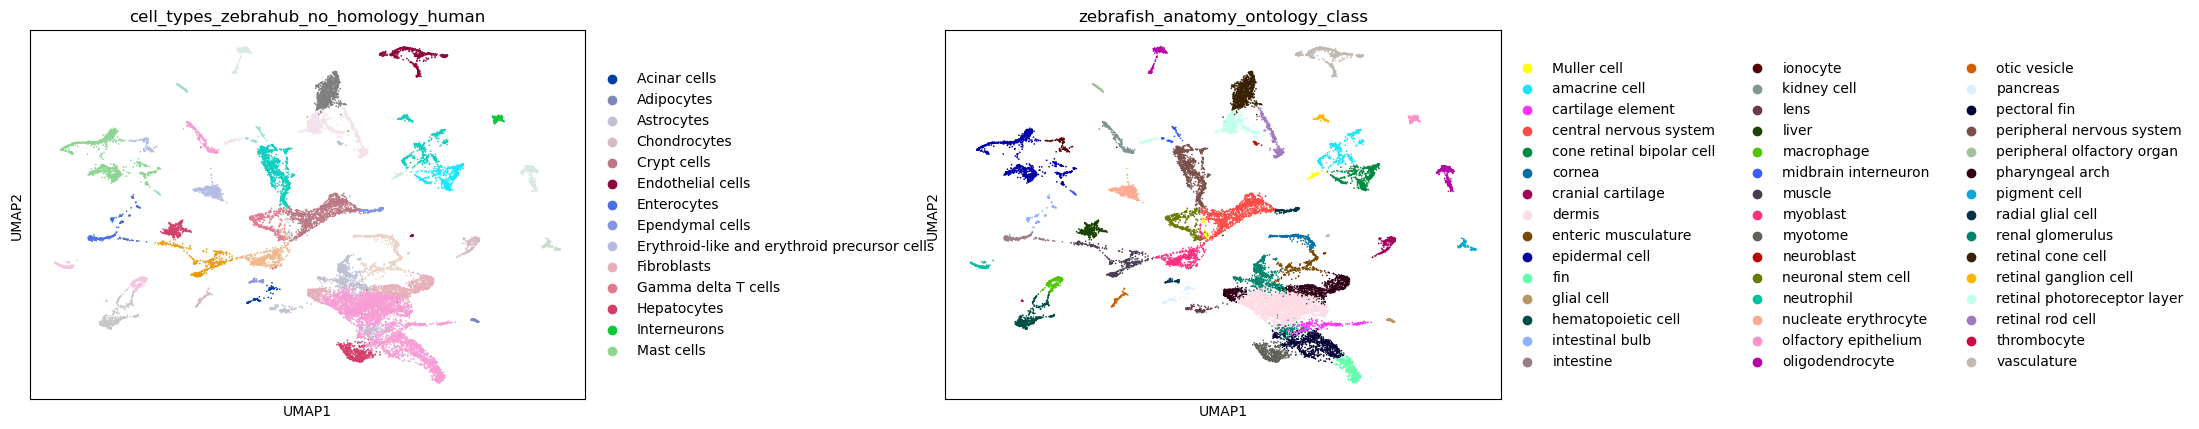

Tables of cell type annotation with clustering zebrafish_anatomy_ontology_class


,Cluster vasculature: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1521,69,194,19
1,Endothelial cells (aorta),335,29,89,14
2,Platelets,219,26,131,10
3,Podocytes,207,19,98,14
4,Hepatocytes,206,18,151,24


,Cluster central nervous system: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Crypt cells,296,8,18,10
1,Immature neurons,277,8,38,21
2,Oligodendrocytes,269,25,92,20
3,Neural stem/precursor cells,259,12,58,12
4,Basophils,240,18,73,21


,Cluster pectoral fin: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Proximal tubule cells,416,11,79,22
1,Hepatocytes,240,18,151,19
2,Luminal epithelial cells,189,9,49,9
3,Mast cells,129,9,141,22
4,Endothelial cells (aorta),117,15,89,17


,Cluster retinal cone cell: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Purkinje neurons,927,7,61,24
1,Olfactory epithelial cells,436,26,131,27
2,Germ cells,309,20,143,22
3,Erythroid-like and erythroid precursor cells,231,12,72,20
4,Interneurons,181,25,224,16


...

,Cluster otic vesicle: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Chondrocytes,102,10,52,18
1,Pancreatic progenitor cells,87,6,17,12
2,Podocytes,86,29,98,18
3,Mesangial cells,82,14,59,17
4,Endothelial cells,73,21,194,18


,Cluster thrombocyte: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Platelets,182,26,131,11
1,Mesangial cells,104,8,59,24
2,Endothelial cells,79,20,194,19
3,Hematopoietic stem cells,50,19,91,10
4,Olfactory epithelial cells,43,22,131,24


,Cluster Muller cell: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Oligodendrocytes,148,21,92,20
1,Podocytes,115,23,98,18
2,Olfactory epithelial cells,101,30,131,24
3,Neurons,87,35,205,20
4,Endothelial cells,87,23,194,17


Output folder: ./annotation/zebrahub_no_homology_mouse/ranked/output/zebrafish_anatomy_ontology_class/ 
DB file: /mnt/workspace/mkessle/projects/annotate_by_marker_and_features/notebooks/zebrahub_no_homology_mouse 
Cluster folder: ./annotation/zebrahub_no_homology_mouse/ranked/clusters/zebrafish_anatomy_ontology_class/ 
Tissue: all
Created folder: ./annotation/zebrahub_no_homology_mouse/ranked/output/zebrafish_anatomy_ontology_class
Writing ranked cluster file sample.cluster_vasculature (1/45)
Writing ranked cluster file sample.cluster_central nervous system (2/45)
Writing ranked cluster file sample.cluster_pectoral fin (3/45)
Writing ranked cluster file sample.cluster_retinal cone cell (4/45)
Writing ranked cluster file sample.cluster_intestine (5/45)
Writing ranked cluster file sample.cluster_peripheral nervous system (6/45)
Writing ranked cluster file sample.cluster_pharyngeal arch (7/45)
Writing ranked cluster file sample.cluster_hematopoietic cell (8/45)
Writing ranked cluster fil

/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/home/mkessle/.conda/envs/marker-repo/lib/python3.11/site-packages/scanpy/plotting/_tools/scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


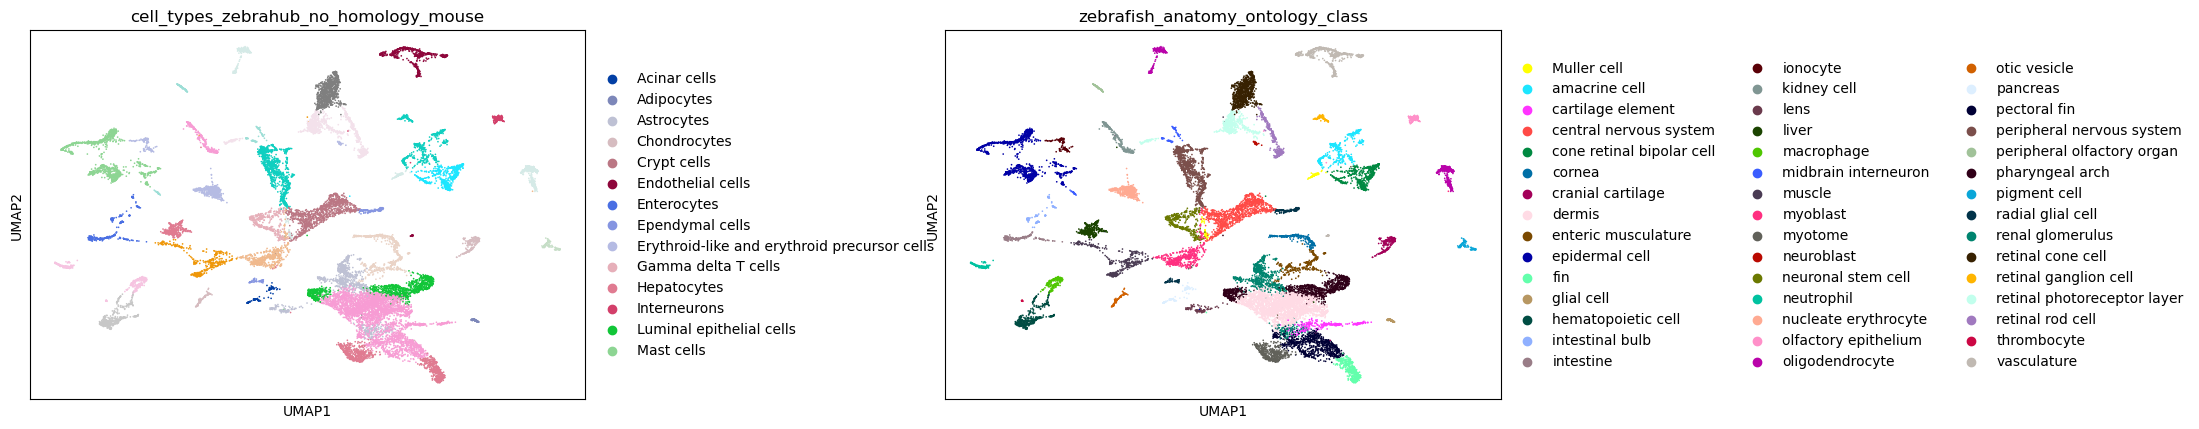

Tables of cell type annotation with clustering zebrafish_anatomy_ontology_class


,Cluster vasculature: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Endothelial cells,1515,68,194,19
1,Endothelial cells (aorta),328,29,93,14
2,Platelets,225,24,122,9
3,Hepatocytes,214,18,140,24
4,Podocytes,206,19,99,14


,Cluster central nervous system: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Crypt cells,296,8,18,10
1,Immature neurons,277,8,38,21
2,Oligodendrocytes,269,25,92,20
3,Neural stem/precursor cells,257,12,59,12
4,Hematopoietic stem cells,224,13,87,19


,Cluster pectoral fin: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Proximal tubule cells,399,11,86,22
1,Hepatocytes,249,18,140,19
2,Luminal epithelial cells,200,9,44,9
3,Embryonic stem cells,119,10,78,15
4,Endothelial cells (aorta),115,15,93,17


,Cluster retinal cone cell: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Purkinje neurons,927,7,61,24
1,Olfactory epithelial cells,428,26,136,27
2,Germ cells,291,19,160,23
3,Erythroid-like and erythroid precursor cells,228,12,74,20
4,Interneurons,180,25,227,16


...

,Cluster peripheral olfactory organ: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Olfactory epithelial cells,702,72,136,21
1,Neurons,267,48,214,18
2,Ependymal cells,266,26,60,20
3,Ciliated cells,196,6,18,18
4,Germ cells,194,30,160,23


,Cluster lens: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Astrocytes,78,11,66,19
1,Podocytes,64,16,99,10
2,Hematopoietic stem cells,54,8,87,17
3,Melanocytes,48,5,42,26
4,Enteric neurons,44,7,69,16


,Cluster otic vesicle: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Chondrocytes,103,10,51,18
1,Pancreatic progenitor cells,87,6,17,12
2,Podocytes,86,29,99,18
3,Mesangial cells,81,14,60,17
4,Endothelial cells,73,21,194,18


,Cluster thrombocyte: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Platelets,188,26,122,11
1,Mesangial cells,103,8,60,24
2,Endothelial cells,79,20,194,19
3,Hematopoietic stem cells,51,19,87,10
4,Luminal epithelial cells,46,5,44,14


,Cluster Muller cell: Cell type,Score,Hits,Number of marker genes,Mean of UI
0,Oligodendrocytes,148,21,92,20
1,Podocytes,114,23,99,18
2,Mast cells,107,24,159,22
3,Olfactory epithelial cells,99,30,136,24
4,Endothelial cells,87,23,194,17


In [10]:
for marker_list in marker_lists:
    name = marker_list.split("/")[-1]
    annotation_dir = f"./annotation/{name}"
    
    # Annotate
    annot.annot_ct(adata, output_path=annotation_dir, db_path=marker_list,
                   cluster_column=f"{column}", rank_genes_column=rank_genes_column, 
                   ct_column=f"cell_types_{name}")
    
    # Plot annotation
    sc.pl.umap(adata, color=[f'cell_types_{name}', f'{column}'], wspace=0.5)

    # Show scores and alternate cell types of eacht cluster
    print(f"Tables of cell type annotation with clustering {column}")
    annot.show_tables(annotation_dir=annotation_dir, n=5, clustering_column=column)

### Compare cell type annotations

In [11]:
compare_df = annot.compare_cell_types(adata, column, marker_lists)

In [12]:
display(compare_df)

,cell_types_zebrahub_no_homology_human,cell_types_zebrahub_no_homology_mouse
zebrafish_anatomy_ontology_class,,
Muller cell,Oligodendrocytes,Oligodendrocytes
amacrine cell,Neurons,Neurons
cartilage element,Proximal tubule cells,Proximal tubule cells
central nervous system,Crypt cells,Crypt cells
cone retinal bipolar cell,Trigeminal neurons,Trigeminal neurons
cornea,Mesangial cells,Mesangial cells
cranial cartilage,Chondrocytes,Chondrocytes
dermis,Proximal tubule cells,Proximal tubule cells
enteric musculature,Mesangial cells,Mesangial cells
